# Introduccion

## Laboratorio N°2

*   Asignatura: Computacion paralela y distribuida
*   Alumno: Elliot Ankatu acevedo
*   Fecha: 23/04/2026
*   Seccion: 412
*   Entorno: Google Colab

# Objetivo

Familiarizarse con los modelos de computación paralela, taxonomías de Flynn y métricas de desempeño (speedup, eficiencia y escalabilidad) mediante experimentos prácticos en Python, midiendo y comparando tiempos de ejecución entre implementaciones secuenciales, vectorizadas y paralelas, con el fin de desarrollar criterios cuantitativos y cualitativos para decidir cuándo es conveniente paralelizar una aplicación.

# Librerias

In [1]:
import time
import math, random
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import Pool
from concurrent.futures import ThreadPoolExecutor

# Ejercicio 1 — Línea base y comparación vectorizada

Propósito: obtener una línea base secuencial y comparar con una implementación vectorizada (numpy)
para discutir diferencias entre optimización algorítmica y paralelismo.

#### 1. a) Medición secuencial (tarea CPU-bound simple).

1. Implementar una función que calcule la suma de la transformación f(x) = √x+log(1+x) para
x ∈{1...n} de forma explícita (bucle Python).

2. Medir tiempo usando time.perf_counter() para varios n (p. ej. $10^{5}, 3 · 10^{5}, 6 · 10^{5}$).

#### 1. b) Versión vectorizada con numpy.

1. Reescribir la misma operación usando numpy (operaciones vectoriales).

2. Medir tiempos y calcular speedup S = Tsecuencial/Tvectorizado.

3. Discutir por qué la vectorización puede producir "speedup" sin paralelismo

#### Codigo

##### Funciones

In [ ]:
def Transformation_sec(n):
    S = 0.0
    S = sum([math.sqrt(i) + math.log(i+1) for i in range(1,n+1)])
    return S

def Transformation_vec(n):
    a = np.arange(1, n+1)
    return np.sqrt(a).sum() + np.log(a + 1).sum()

##### Mediciónes

In [3]:
ts = []
tv = []
S_list = []

In [4]:
TIME = [100_000, 300_000, 600_000]

for i in TIME:
    # Secuencial
    start = time.perf_counter()
    Sec = Transformation_sec(i)
    fin = time.perf_counter()

    ts.append(fin - start)

    # Vectorizada
    start = time.perf_counter()
    vec = Transformation_vec(i)
    fin = time.perf_counter()

    tv.append(fin - start)
    S = ts[-1] / tv[-1]
    S_list.append(S)
    print(f"iteracion={i:,} sec={ts[-1]:.4f}s | vec={tv[-1]:.4f}s | S={S:.2f}")

iteracion=100,000 sec=0.0234s | vec=0.0026s | S=8.90
iteracion=300,000 sec=0.0586s | vec=0.0066s | S=8.82
iteracion=600,000 sec=0.1176s | vec=0.0167s | S=7.02


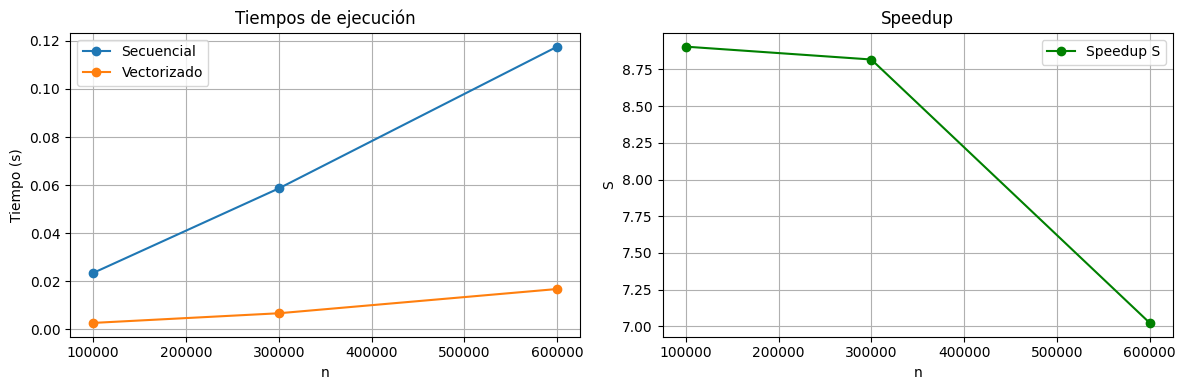

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Tiempos
ax1.plot(TIME, ts, label="Secuencial", marker="o")
ax1.plot(TIME, tv, label="Vectorizado", marker="o")
ax1.set_xlabel("n")
ax1.set_ylabel("Tiempo (s)")
ax1.set_title("Tiempos de ejecución")
ax1.legend()
ax1.grid(True)

# Gráfico 2: Speedup
ax2.plot(TIME, S_list, label="Speedup S", marker="o", color="green")
ax2.set_xlabel("n")
ax2.set_ylabel("S")
ax2.set_title("Speedup")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Ejercicio 2 — Paralelismo práctico y limitaciones
Propósito: explorar speedup y eficiencia mediante ejecuciones paralelas en problemas compuestos por
unidades independientes. Se proponen dos variantes que muestran efectos distintos.

1. Paralelismo tipo "IO/latencia" o trabajo ligero (ThreadPoolExecutor).
    * Diseñar una función que simule trabajo con pausa (por ejemplo, time.sleep() combinado con
        una pequeña operación) para que el uso de hilos muestre beneficios.
    * Ejecutar en serie y con ThreadPoolExecutor con p = 2,4,8 hilos, medir tiempos y calcular S y E = S/p.
2. Paralelismo CPU-bound (multiprocessing).
    * Implementar una función CPU-intensiva (p. ej. cómputo de términos de una integral por cua-
    dratura simple o iteración numérica pesada).
    * Ejecutar en serie y con pool de procesos (p = 2,4) para medir speedup y eficiencia. Nota: en
    Windows y en Jupyter puede ser necesario ejecutar este fragmento como script
    (archivo .py) usando la protección if __name__ == ’__main__’:.*

#### Ejemplo  1. Tipo IO/Latencia

##### Funciones

tarea_io toma un valor n, con una espera de 0.05 segundos retorna n*n.

threads toma un valor p (p = 4, si no se le da un valor en la llamada, por defecto usara 4), empieza a medir el tiempo con start = perf_counter(), crea una lista con datos en un rango de 1 a 40,
con ThreadPoolExecutor(max_workers = p) lo renombra como executor y luego se le aplica map(tarea_io, data) que toma un valor de data y lo evalua en la llamada tarea_io. Finalmente retorna time.perf_counter()
que termina la medicion del tiempo y luego se le resta el tiempo inicial.


In [6]:
def tarea_io(n):
    time.sleep(0.05)
    return n*n

def threads(p = 4):
    start = time.perf_counter()
    data = list(range(1, 40))
    with ThreadPoolExecutor(max_workers = p) as executor:
        executor.map(tarea_io, data)
    return time.perf_counter() - start

##### for

recorre la lista (1,2,4,8) iterandolo sobre i, luego se le ingresa i dentro de la llamada de la funcion threads
luego calcula el Speedup usando el tiempo base ya calculado fuera de la iteracion dividido por los tiempos paralelos en cada hilo, calula la Eficiencia dividiendo el speedup por la cantidad de hilos, imprime Speed, eficiencia, el hilo actual y el tiempo que se demoro en evaluar en esa funcion con i cantidad de hilos

Nota:  

* Speedup(S) : es cuantas veces es mas rapida la version paralela con respecto a la secuencial. $ S =  \frac{T_{serie}}{T_{paralelo}} $
* Eficiencia(E): que tan bien se estan aprovechando los hilos\procesos disponibles. $ E = \frac{S}{p}$ 

In [ ]:
t_base = threads(1)
for i in (1,2,4,8):
    t = threads(i)
    S = t_base/t
    E = S / i
    print(f'threads: {i} | tiempo: {t: .4f} | s : {S:.4f} | E : {E:.4f}')

threads: 1 | tiempo:  1.9571 | s : 1.0001 | E : 1.0001
threads: 2 | tiempo:  1.0045 | s : 1.9494 | E : 0.9747
threads: 4 | tiempo:  0.5022 | s : 3.8950 | E : 0.9738
threads: 8 | tiempo:  0.2527 | s : 7.7696 | E : 0.9712


##### Analisis

Al aumentar los hilos en paralelo, se puede ver que el tiempo que demora el programa en hacer la operacion disminuye, el  **Speedup(S)**  demuestra que con cada iteracion aumenta la rapidez de la paralela
con respecto a la secuencial hasta que se vuelve 7.7 veces mas rapida,como $ S(p) > 1 $ mejora el rendimiento, sin embargo la **Eficiencia** disminuye un poco pero segun las reglas $ E(p) > 0.7 $, sigue manteniendo una buena Eficiencia.Esto se debe a que la tarea es de tipo I/O (time.sleep()), donde mientras un hilo espera, los demás pueden ejecutarse sin interferirse, lo que hace que el paralelismo con hilos sea muy efectivo en este caso.

#### Ejemplo 2. CPU-bound

##### Funciones

cpu toma un valor x dado por el valor que se le da la llamada, se inicializa una variable S = 0.0, luego se itera en un rango de 200_000, sumando y evaluando la ecuacion y guardando los resultados en S en cada iteracion.

eva_process toma un valor p, luego empieza a medir el tiempo con start_p = time.perf, se crea y almacena una lista con datos en un rango de 1 a 40, multiprocessing.Pool se renombra como multiP y se le aplica map usando la funcion cpu y los datos de la lista data_p como parametros. Finalmente se retorna la diferencia entre el tiempo final e inicial

if __name__ == '__main__' verifica si el script se esta ejecutando directamente con el programa o si es importado como modulo de otro script.


for recorre la lista (1,2,4) iterandolo sobre i, luego se le ingresa i dentro de la llamada de la funcion eva_process, calcula el Speedup usando el tiempo base ya calculado fuera de la iteracion dividido por los tiempos paralelos en cada proceso, calula la Eficiencia dividiendo el speedup por la cantidad de procesos, imprime Speed, eficiencia, el proceso actual y el tiempo que se demoro en evaluar en esa funcion con i cantidad de procesos

In [8]:
%%writefile cpu_work.py

import time
import math
import multiprocessing

def cpu(x):
    S = 0.0
    for i in range(200_000):
        S+= (x*2) + (i**2)*math.log(x+1) * 0.01
    return S

def eva_process(p):
    start_p = time.perf_counter()
    data_p = list(range(1,40))
    with multiprocessing.Pool(processes = p) as multiP:
        multiP.map(cpu, data_p)
    return time.perf_counter() - start_p

if __name__ == '__main__':   
    t_base_p = eva_process(1)
    for i in (1,2,4):
        t_p = eva_process(i)
        S = t_base_p / t_p
        E = S / i
        print(f'p={i} | tiempo={t_p:.4f}s | S={S:.2f} | E={E:.2f}')

Writing cpu_work.py


In [9]:
!python cpu_work.py

p=1 | tiempo=3.1793s | S=0.57 | E=0.57
p=2 | tiempo=1.9239s | S=0.95 | E=0.47
p=4 | tiempo=1.9308s | S=0.94 | E=0.24


##### Analisis

Colab:  
al aumentar los procesos en paralelo en Google Colab, al tener capacidad limitada de CPU(1), esto queda demostrado por los datos medidos, **Speedup(S)** da un valor $ S(p) < 1$, dando a entender que el rendimiento paralelo empeora en comparacion a la secuencial. **Eficiencia(E)** empeora en cada iteracion dando $ E(p) < 0.5$, el overhead de crear y coordinar procesos supera el beneficio del paralelismo al tener solo 1 CPU disponible

|    P     | tiempo(s)| Speedup(S)  |    Eficiencia(E)  |
|----------|----------|-------------|-------------------|
|   1      | 3.1793   | 0.57        |0.57               |
| 2        | 1.9239   | 0.95        |0.47               |
| 4        | 1.9308   | 0.94        |0.24               |

Local:
al aumentar los procesos en un entorno local, al tener un cpu con mas capacidad que el que brinda colab, se puede aprovechar mas los recursos, queda demostrado por los resultados que entre mas aumentan los procesos, se puede verificar que es mas eficiente, **Speedup(S)** mantiene un valor $S(p) > 1$ lo que demuestra que el rendimiento mejora, la **Eficiencia(E)** disminuye en cada iteracion pero se mantiene sobre $E(p) > 0.7$, por lo que se demuestra que mantiene una buena eficiencia.
|    P     | tiempo(s)| Speedup(S)  |    Eficiencia(E)  |
|----------|----------|-------------|-------------------|
|   1      | 1.7111   | 1.34        |1.34               |
| 2        | 0.9908   | 2.31        |1.15               |
| 4        | 0.6955   | 3.29        |0.82               |

##### Grafico comparativo

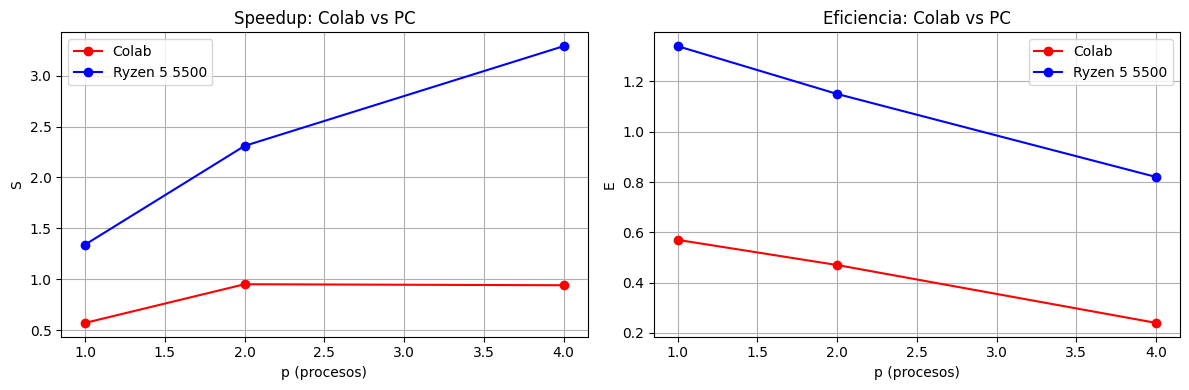

In [11]:
# Resultados
p_vals = [1, 2, 4]

# Colab
S_colab = [0.57, 0.95, 0.94]
E_colab = [0.57, 0.47, 0.24]

# PC Ryzen 5 5500
S_pc = [1.34, 2.31, 3.29]
E_pc = [1.34, 1.15, 0.82]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Speedup
ax1.plot(p_vals, S_colab, label="Colab", marker="o", color="red")
ax1.plot(p_vals, S_pc, label="Ryzen 5 5500", marker="o", color="blue")
ax1.set_xlabel("p (procesos)")
ax1.set_ylabel("S")
ax1.set_title("Speedup: Colab vs PC")
ax1.legend()
ax1.grid(True)

# Eficiencia
ax2.plot(p_vals, E_colab, label="Colab", marker="o", color="red")
ax2.plot(p_vals, E_pc, label="Ryzen 5 5500", marker="o", color="blue")
ax2.set_xlabel("p (procesos)")
ax2.set_ylabel("E")
ax2.set_title("Eficiencia: Colab vs PC")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Ejercicio 3 — Decisión estratégica

Propósito: aplicar lo aprendido a un caso de ciencia de datos y formular una recomendación técnica.

3. Procesamiento por lotes independiente.

    * Simular varios ficheros/lotes donde cada lote es procesado mediante una función costosa.
    * Ejecutar secuencialmente y (si es posible) con pool de procesos, medir tiempos.
3. Diagnóstico y recomendación.

    * Calcular S y E para la mejor configuración obtenida.
    * Decidir y justificar: escalar verticalmente (más núcleos), 
         escalar horizontalmente (distribución),
        o permanecer secuencial. Fundamente la recomendación en independencia de lotes, costos de
        comunicación y sobrecarga de coordinación.

#### Ejemplo 3: Procesamiento por lotes independiente

##### Funciones

In [ ]:
def lotes_ind(seed):
    random.seed(seed)
    data_semilla = [random.random() for i in range(80_000)]
    result = sum(i**2 for i in data_semilla)
    return result

def secuencial(lotes):
    start_secuencial = time.perf_counter()
    for i in lotes:
        lotes_ind(i)
    return time.perf_counter() - start_secuencial

def procesal(lotes, p):
    start_procesal = time.perf_counter()
    with ProcessPoolExecutor(max_workers=p) as executor:
        executor.map(lotes_ind, lotes)
    return time.perf_counter() - start_procesal


In [23]:
lotes = list(range(8))
tsecuencial = secuencial(lotes)
tprocessal = processal(lotes, p = 4)

S = tsecuencial / tprocessal
E = S / 4

print(f'Secuencial: {tsecuencial:.4f} | Procesos(p = 4): {tprocessal:.4f} | Speedup(S): {S:.4f} | Eficiencia(E) : {E:.4f}')

Secuencial: 0.1243 | Procesos(p = 4): 0.2327 | Speedup(S): 0.5340 | Eficiencia(E) : 0.1335


##### Analisis

El paralelismo solo es eficiente cuando el tamaño de los lotes y la cantidad de trabajo es suficiente para amortizar el overhead de crear procesos. Con lotes pequeños (80k) el overhead supera el beneficio, mientras que con lotes más grandes (500k) y mayor cantidad (64 lotes) se obtiene S = 2.87 y E = 0.72.

| Configuración  | Entorno | Secuencial | Procesal(p=4)   | Speedup(S)    | Eficiencia(E)    |
|----------------|---------|------------|-----------------|---------------|------------------|
| 8 lotes, 80k   | Colab   | 0.12s      | 0.23s           | 0.53          | 0.13             |
| 8 lotes, 80k   | PC      | 0.09s      | 0.30s           | 0.29          | 0.07             |
| 8 lotes, 500k  | PC      | 0.66s      | 0.54s           | 1.22          | 0.31             |
| 32 lotes, 500k | PC      | 2.47s      | 1.14s           | 2.16          | 0.54             |
| 64 lotes, 500k | PC      | 4.84s      | 1.69s           | 2.87          | 0.72             |

##### Recomendacion tecnica

Para lotes pequeños (8 lotes, 80k elementos), la recomendación es mantenerse secuencial, ya que el overhead de crear procesos supera el beneficio, obteniendo S = 0.29 y E = 0.07. A medida que aumentan los lotes y el tamaño de los datos, conviene escalar verticalmente (más núcleos en la misma máquina), como se demostró con 64 lotes de 500k elementos donde se obtuvo S = 2.87 y E = 0.72, superando el umbral mínimo de eficiencia. Esto es posible porque los lotes son completamente independientes entre sí, lo que minimiza los costos de comunicación y sincronización. Cuando los datos sean demasiado masivos para una sola máquina, se recomienda escalar horizontalmente (distribución entre múltiples nodos), aunque esto introduce costos adicionales de red y coordinación que deben evaluarse.